# Experiment 3 — class-imbalance robustness (PD)

How AUC and the prevalence-corrected **AP_normalized** hold up as the minority-class proportion is driven down (no HPO; the four leading methods). Pooled curves in four views for each metric, then per-dataset raw points, a degradation table, and a summary of both **trajectories**. Figures → `figures/experiment3/`.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.paths import results_root
from src.methods.method_config import HPO_METHODS          # tuned methods -> HPO time x n_trials
from src.visualizations.experiment_plots import (
    apply_style, reset_figure_dir, load_summary,
    performance_heatmap, rank_heatmap, hpo_improvement_bars,
    compute_time_bars, runtime_performance_scatter,
    learning_curve, imbalance_curve, per_dataset_sweep_curves,
    sweep_evolution_summary, pd_summary_text, lgd_summary_text,
)
apply_style()

RESULTS_ROOT = results_root()          # override here if your copy lives elsewhere
SUMMARY_DIR  = RESULTS_ROOT / 'summaries'
FIGURES_DIR  = reset_figure_dir(PROJECT_ROOT / 'figures' / 'experiment3')
print('results:', RESULTS_ROOT, '| figures:', FIGURES_DIR)

results: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results | figures: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\figures\experiment3


In [2]:
df = load_summary(SUMMARY_DIR, experiment='experiment3', task='pd', aggregated=False)
print(f'{df["method"].nunique()} methods, {df["dataset"].nunique()} datasets, '
      f'{df["sweep_value"].nunique()} sweep points')

4 methods, 6 datasets, 296 sweep points


## 1. AUC vs minority-class proportion — pooled over datasets

Four views (one line per method, mean over datasets): raw points, moving average, relative to each method's own best, and the moving average of that relative curve.

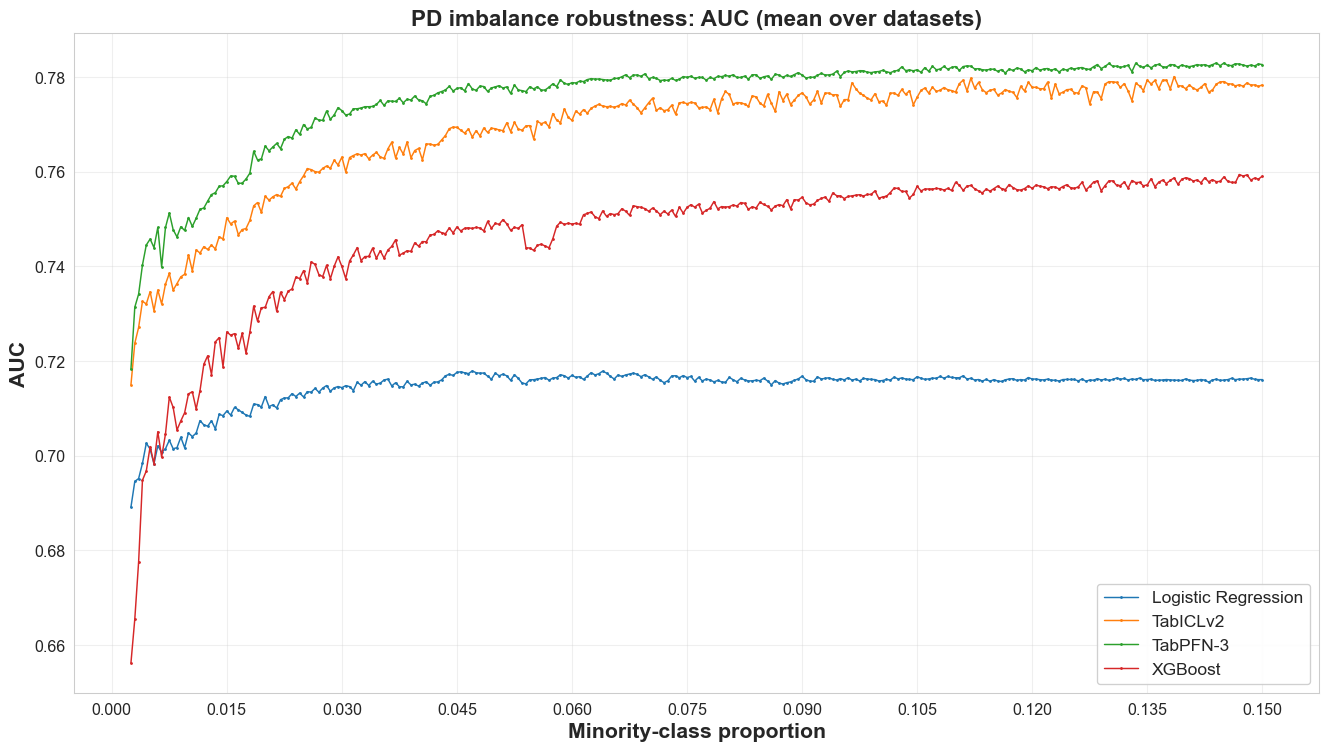

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment3/pd_imbalance_curve_auc.pdf')

In [3]:
imbalance_curve(df, 'AUC', task_name='PD', out_dir=FIGURES_DIR)

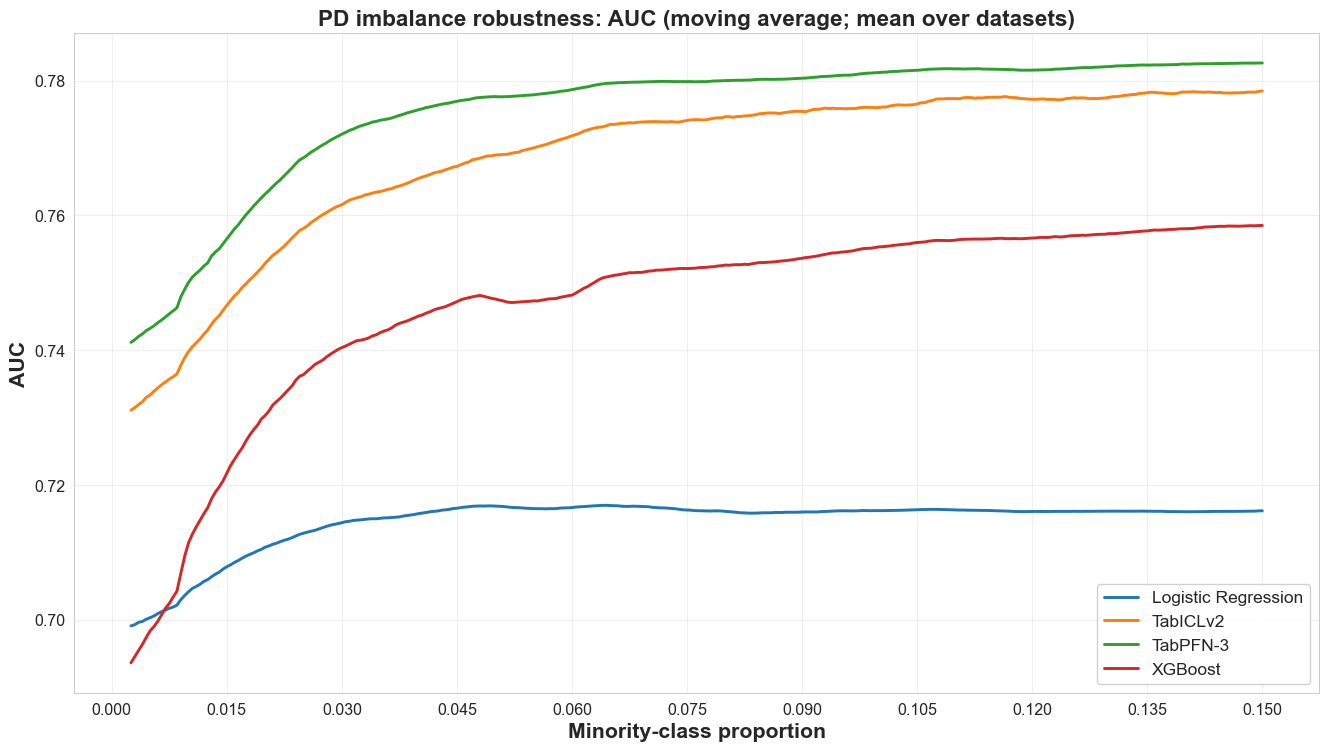

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment3/pd_imbalance_curve_auc_smooth.pdf')

In [4]:
imbalance_curve(df, 'AUC', task_name='PD', smooth=True, out_dir=FIGURES_DIR)

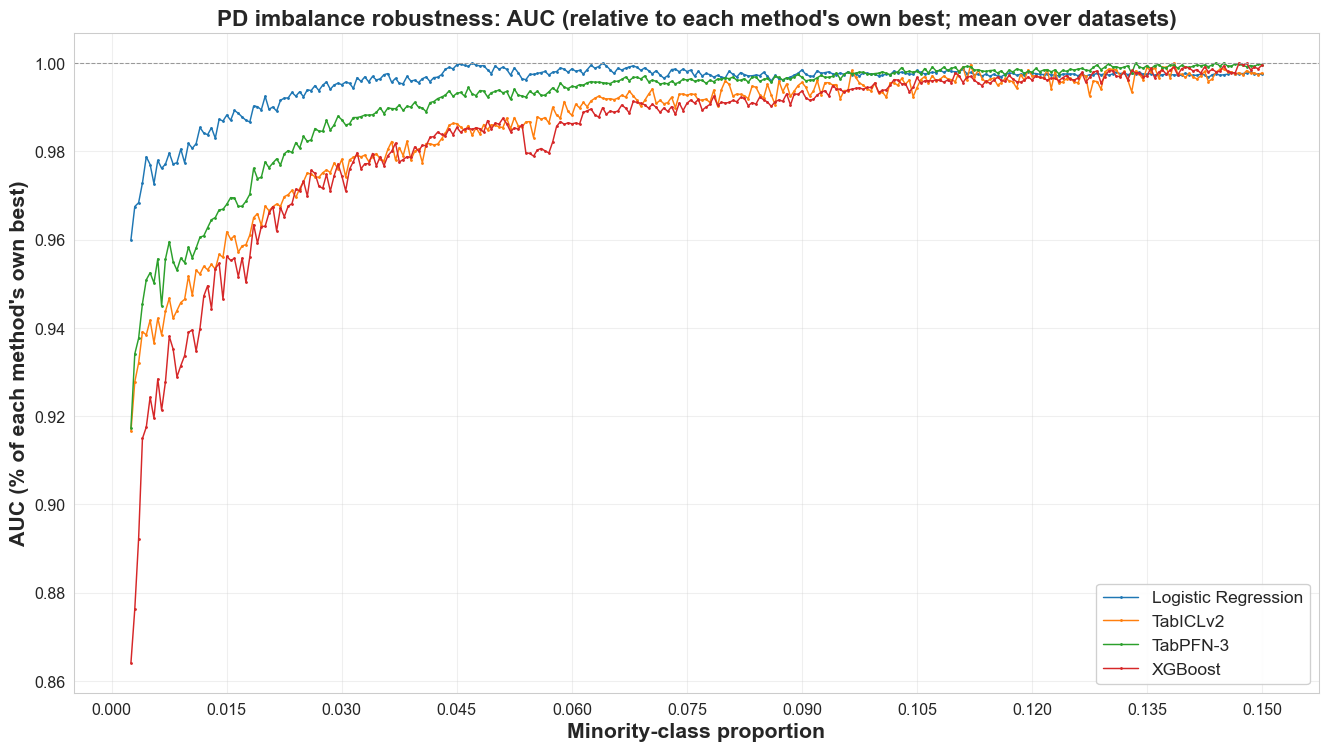

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment3/pd_imbalance_curve_auc_relative.pdf')

In [5]:
imbalance_curve(df, 'AUC', task_name='PD', relative=True, out_dir=FIGURES_DIR)

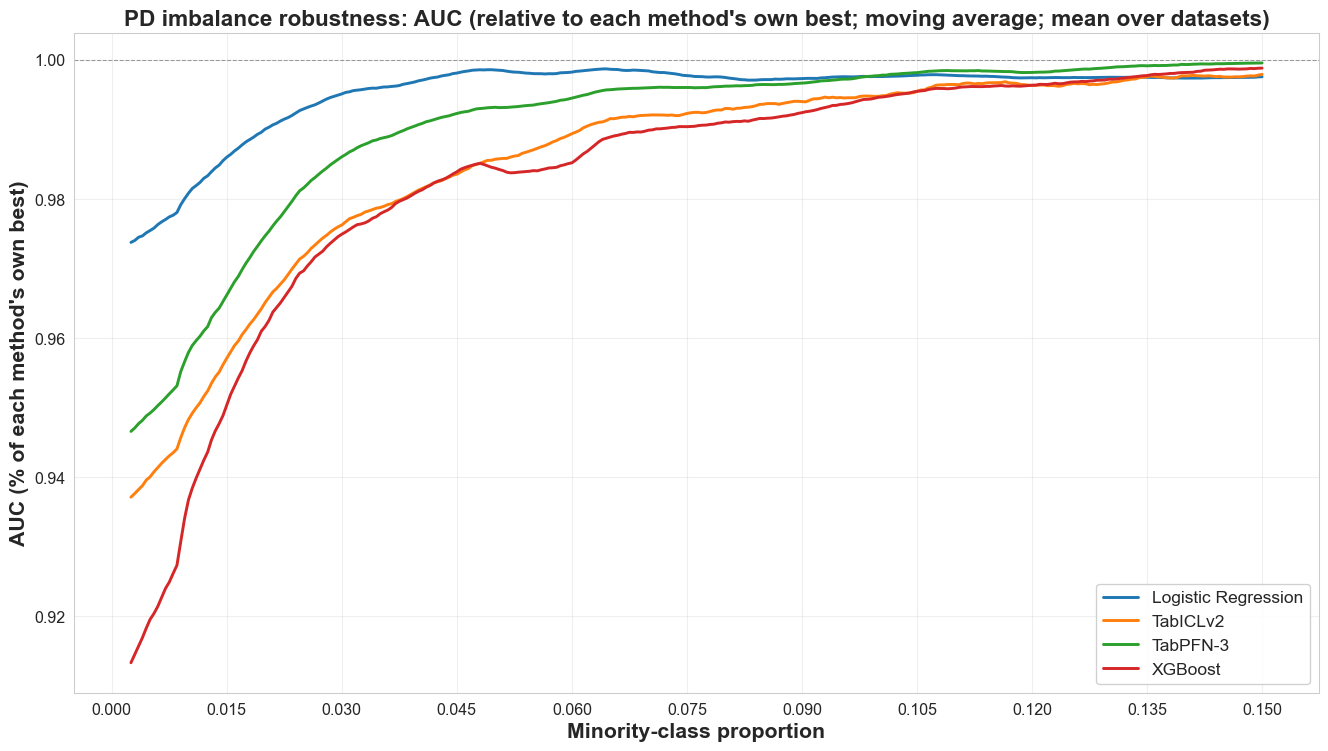

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment3/pd_imbalance_curve_auc_relative_smooth.pdf')

In [6]:
imbalance_curve(df, 'AUC', task_name='PD', relative=True, smooth=True, out_dir=FIGURES_DIR)

## 2. AP_normalized (prevalence-corrected) — pooled over datasets

Same four views. AP_normalized = (AP − π)/(1 − π) removes the prevalence baseline, so it is comparable across imbalance levels and datasets.

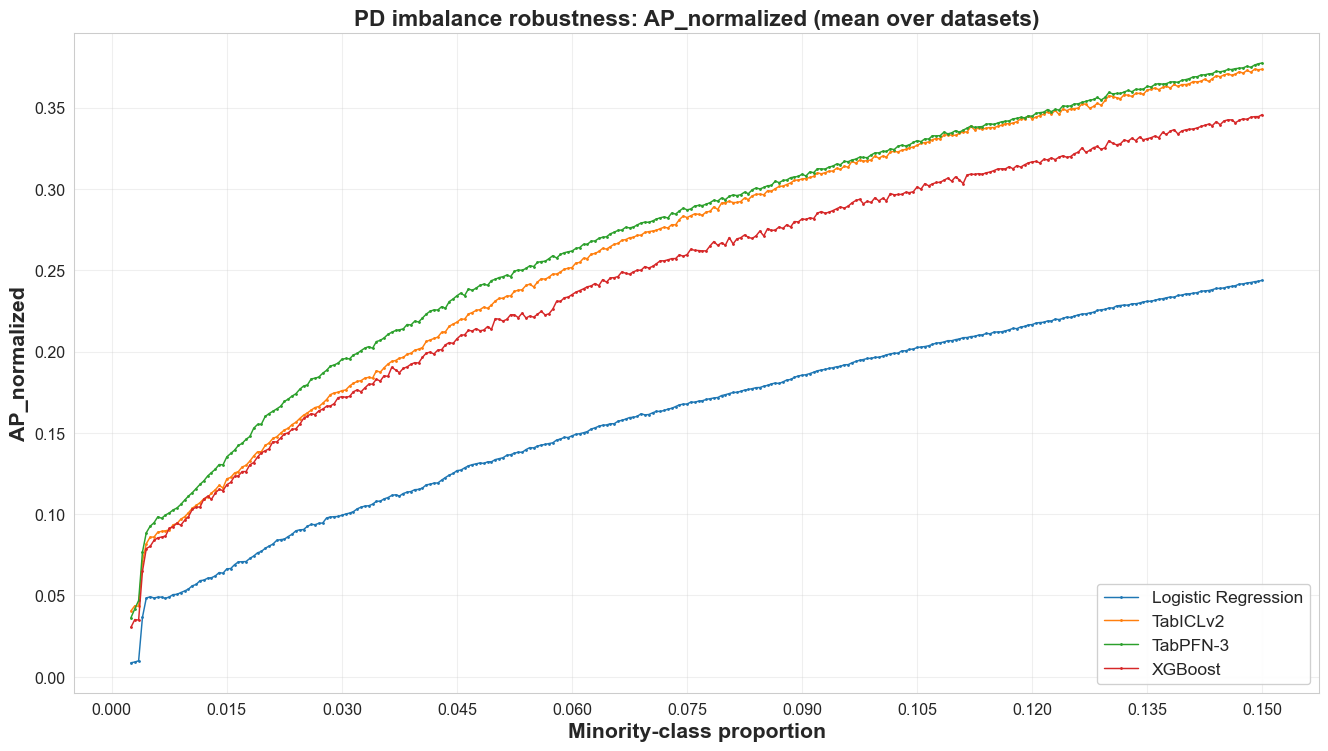

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment3/pd_imbalance_curve_ap_normalized.pdf')

In [7]:
imbalance_curve(df, 'AP_normalized', task_name='PD', out_dir=FIGURES_DIR)

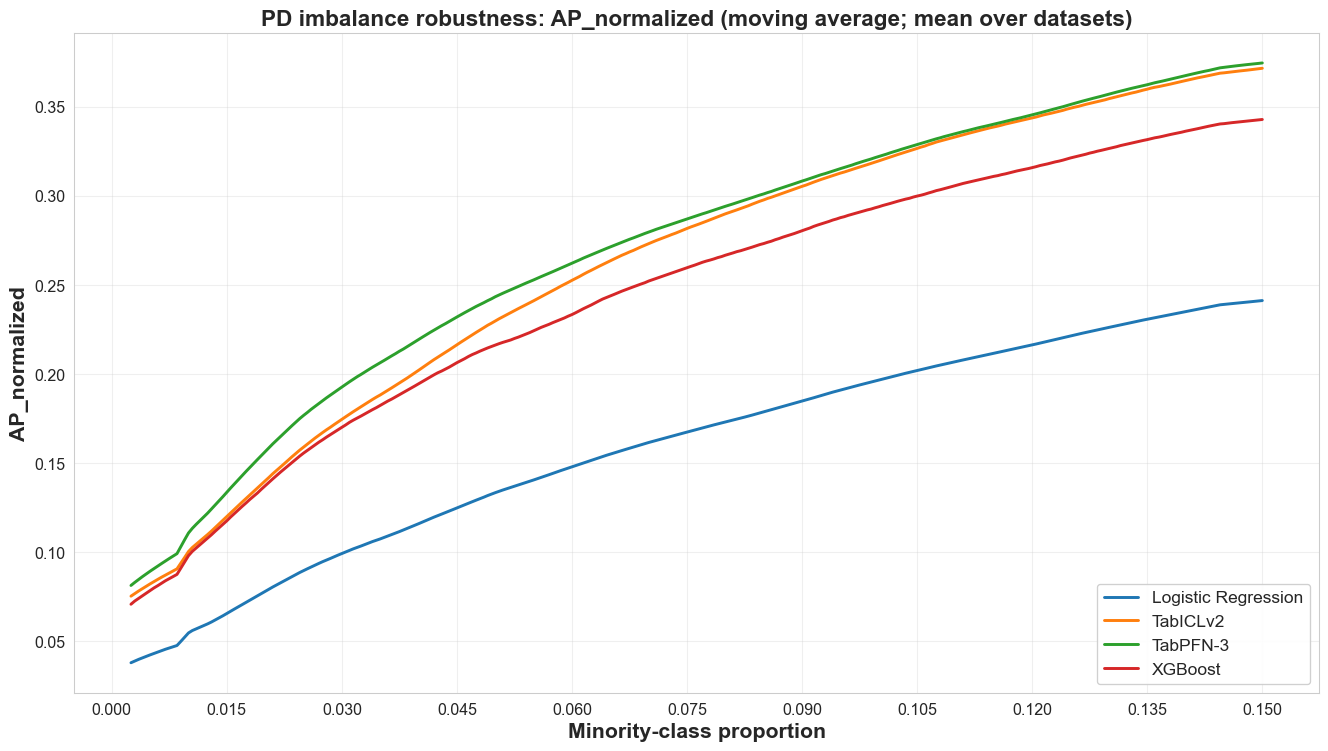

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment3/pd_imbalance_curve_ap_normalized_smooth.pdf')

In [8]:
imbalance_curve(df, 'AP_normalized', task_name='PD', smooth=True, out_dir=FIGURES_DIR)

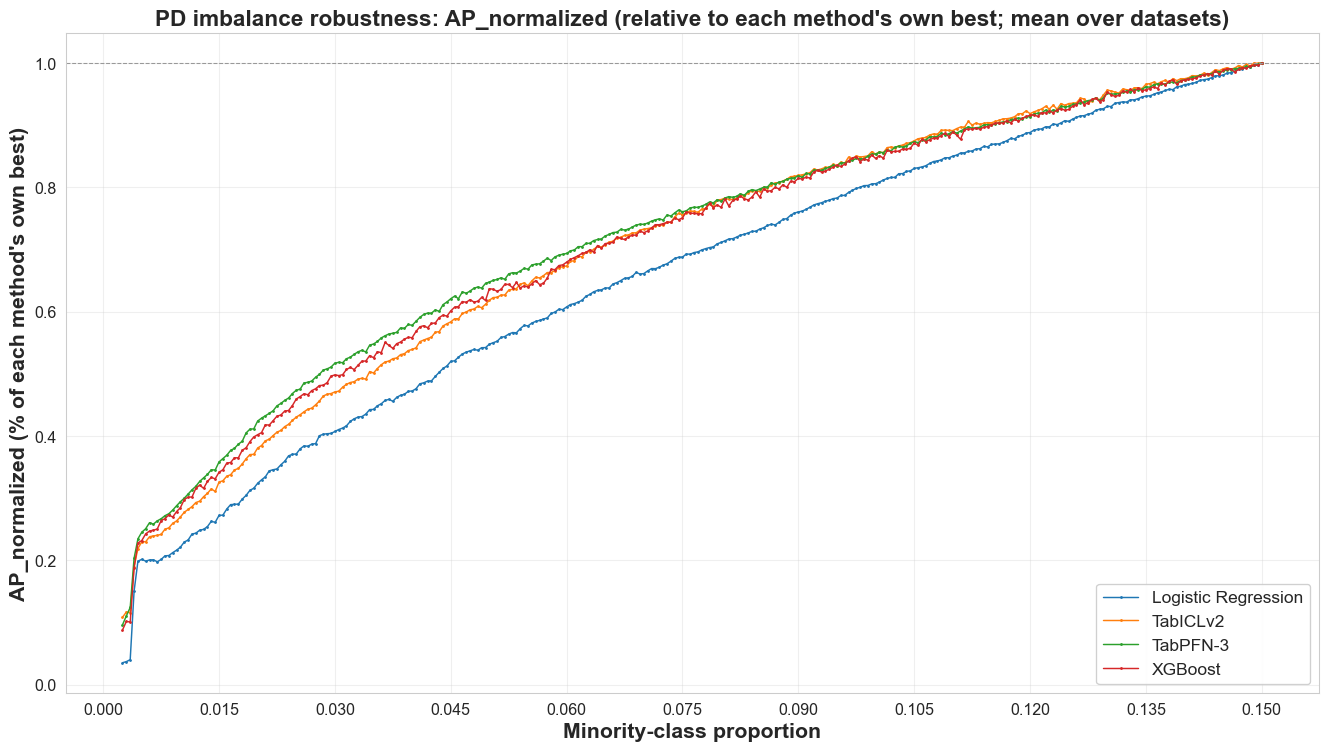

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment3/pd_imbalance_curve_ap_normalized_relative.pdf')

In [9]:
imbalance_curve(df, 'AP_normalized', task_name='PD', relative=True, out_dir=FIGURES_DIR)

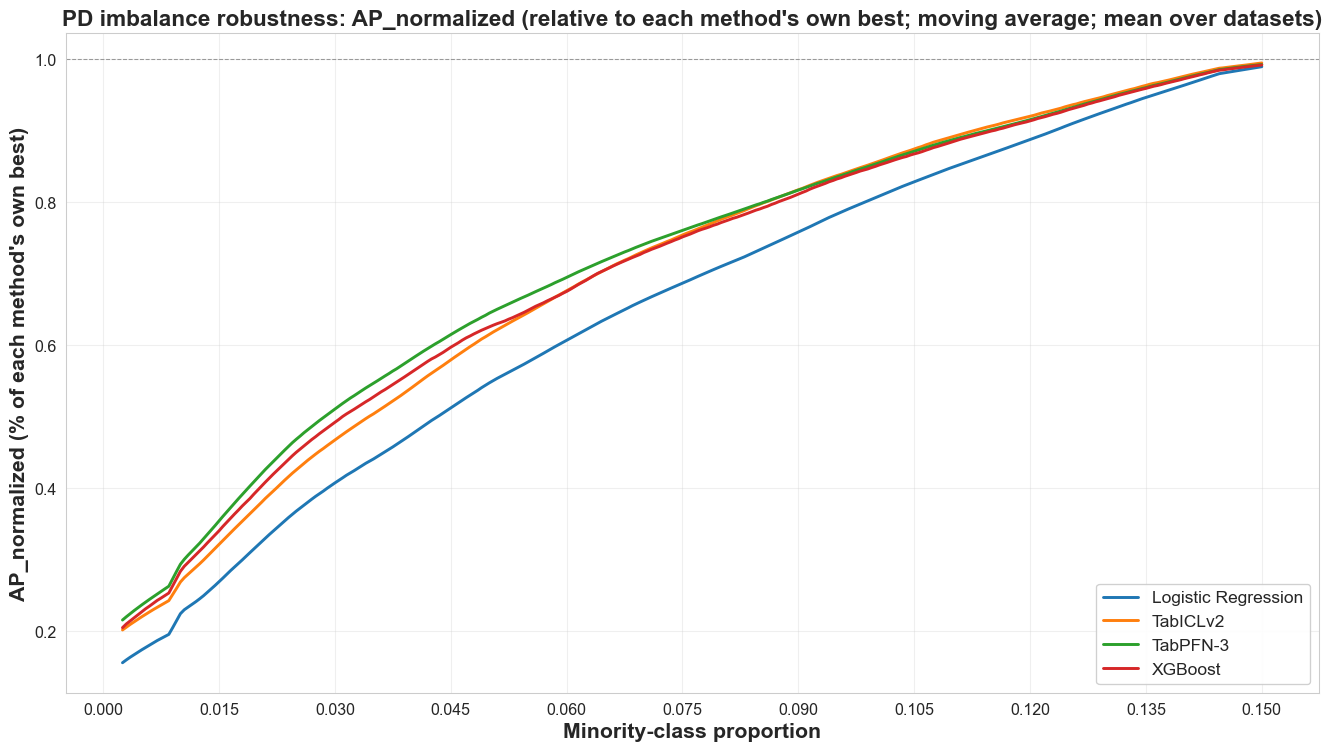

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment3/pd_imbalance_curve_ap_normalized_relative_smooth.pdf')

In [10]:
imbalance_curve(df, 'AP_normalized', task_name='PD', relative=True, smooth=True, out_dir=FIGURES_DIR)

## 3. AUC per dataset (raw points, all methods)

One plot per dataset.

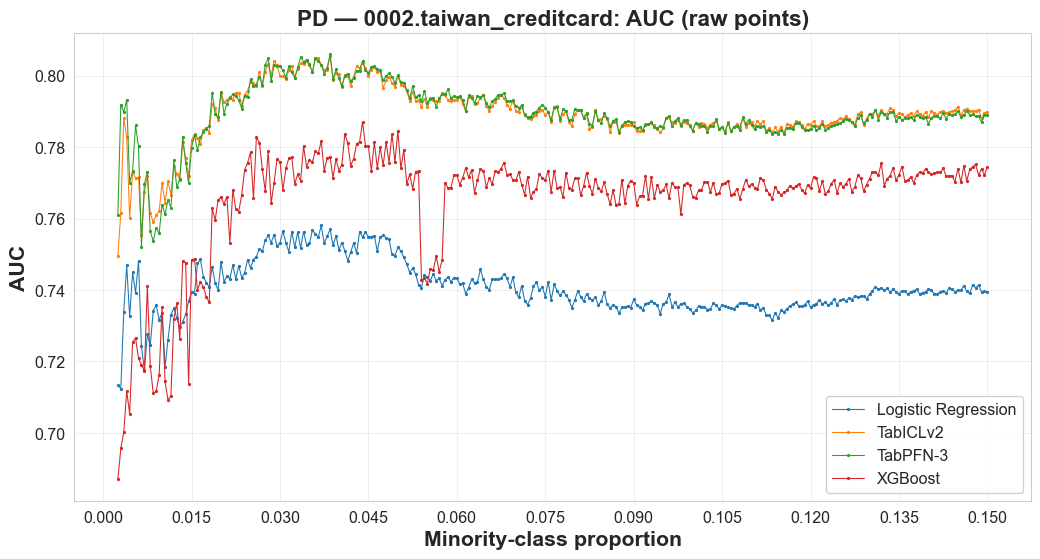

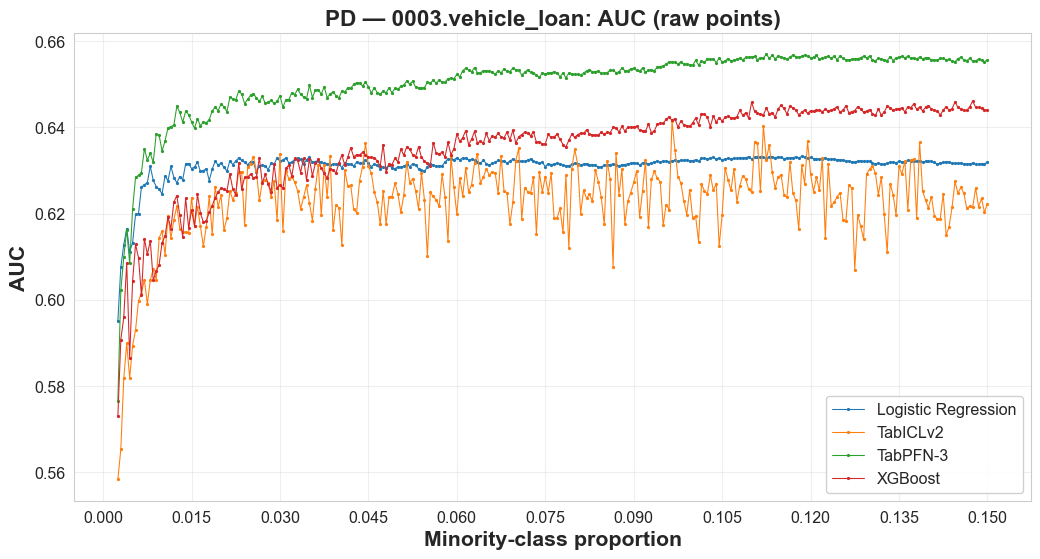

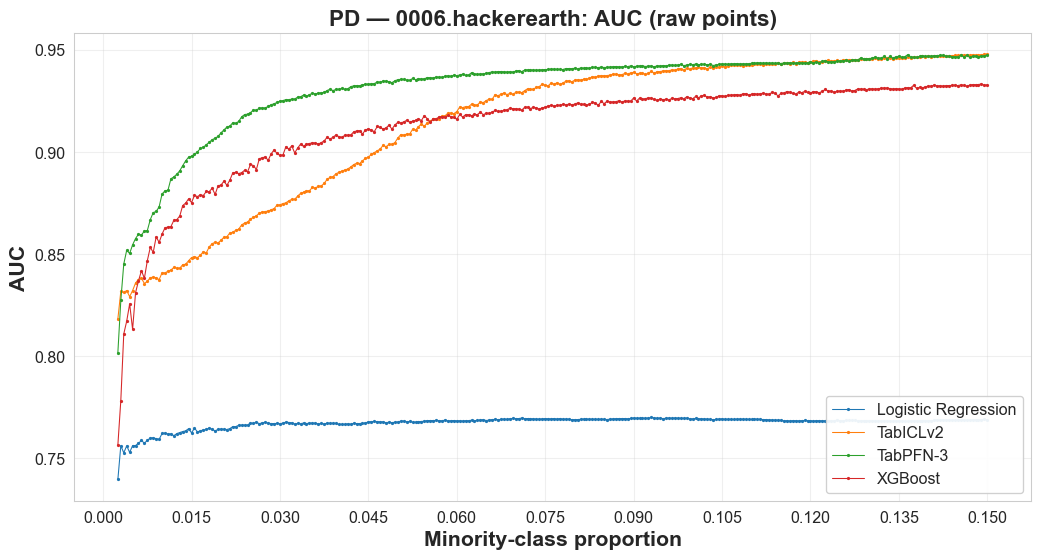

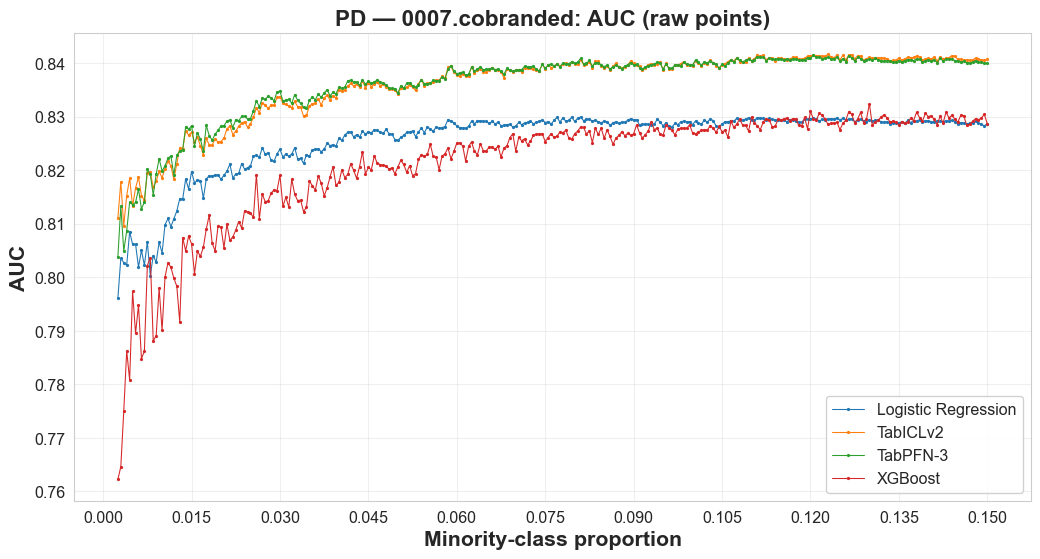

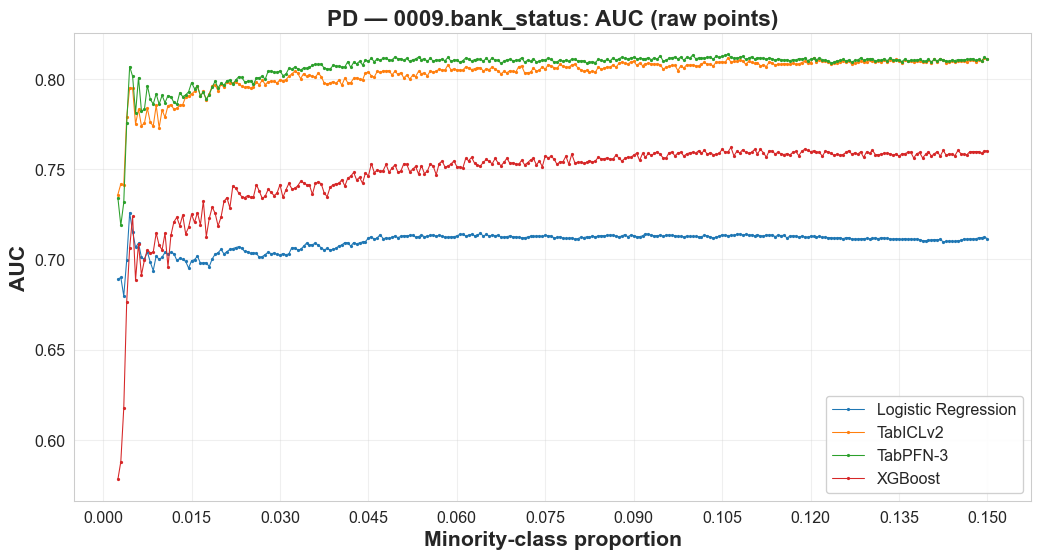

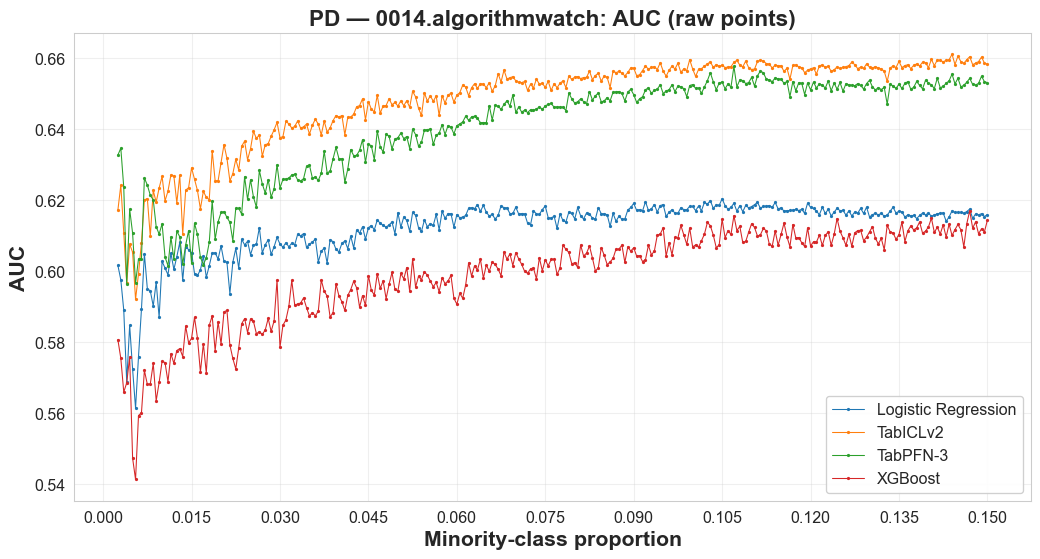

[WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment3/pd_minority_proportion_0002_taiwan_creditcard_auc.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment3/pd_minority_proportion_0003_vehicle_loan_auc.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment3/pd_minority_proportion_0006_hackerearth_auc.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment3/pd_minority_proportion_0007_cobranded_auc.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment3/pd_minority_proportion_0009_bank_status_auc.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment3/pd_minority_proportion_0014_algorithmwatch_auc.pdf')]

In [11]:
per_dataset_sweep_curves(df, 'AUC', sweep_axis='minority_proportion', xlabel='Minority-class proportion', task_name='PD', out_dir=FIGURES_DIR)

## 4. Degradation — AUC at the easiest minus the hardest setting

In [12]:
import pandas as _pd
g = df.groupby(['method','sweep_value'])['metric.AUC'].mean().reset_index()
drop = {m: gg.sort_values('sweep_value').iloc[-1]['metric.AUC']
            - gg.sort_values('sweep_value').iloc[0]['metric.AUC']
        for m, gg in g.groupby('method')}
display(_pd.Series(drop, name='AUC(max minority) - AUC(min minority)').sort_values(ascending=False))

xgboost      0.102835
tabpfn_v3    0.064339
tabicl_v2    0.063325
LogReg       0.026918
Name: AUC(max minority) - AUC(min minority), dtype: float64

## 5. Summary — AUC & AP_normalized evolution over minority proportion

Mean per method across all datasets at a spread of minority-class proportions (not just the most balanced point), so the whole robustness trajectory is visible.

In [13]:
sweep_evolution_summary(df, 'AUC', sweep_axis='minority_proportion', task_name='Experiment 3 — PD')

Experiment 3 — PD — AUC evolution over minority_proportion  (mean across 6 datasets; 16 of 296 sweep points; best average first)
sweep_value  0.0025  0.0125  0.0220  0.0320  0.0420  0.0515  0.0615  0.0715  0.0810  0.0910  0.1010  0.1105  0.1205  0.1305  0.1400  0.1500
method                                                                                                                                     
tabpfn_v3    0.7183  0.7538  0.7649  0.7733  0.7761  0.7779  0.7790  0.7793  0.7805  0.7799  0.7811  0.7814  0.7820  0.7823  0.7823  0.7826
tabicl_v2    0.7150  0.7436  0.7548  0.7638  0.7656  0.7703  0.7731  0.7735  0.7743  0.7743  0.7741  0.7786  0.7778  0.7790  0.7775  0.7783
xgboost      0.6562  0.7211  0.7345  0.7440  0.7467  0.7490  0.7509  0.7509  0.7530  0.7530  0.7548  0.7572  0.7572  0.7581  0.7587  0.7591
LogReg       0.6891  0.7062  0.7118  0.7155  0.7155  0.7169  0.7161  0.7159  0.7160  0.7158  0.7161  0.7165  0.7162  0.7161  0.7162  0.7161

Experiment 3 — PD — AUC as % o

"Experiment 3 — PD — AUC evolution over minority_proportion  (mean across 6 datasets; 16 of 296 sweep points; best average first)\n======================================================================================================================\nsweep_value  0.0025  0.0125  0.0220  0.0320  0.0420  0.0515  0.0615  0.0715  0.0810  0.0910  0.1010  0.1105  0.1205  0.1305  0.1400  0.1500\nmethod                                                                                                                                     \ntabpfn_v3    0.7183  0.7538  0.7649  0.7733  0.7761  0.7779  0.7790  0.7793  0.7805  0.7799  0.7811  0.7814  0.7820  0.7823  0.7823  0.7826\ntabicl_v2    0.7150  0.7436  0.7548  0.7638  0.7656  0.7703  0.7731  0.7735  0.7743  0.7743  0.7741  0.7786  0.7778  0.7790  0.7775  0.7783\nxgboost      0.6562  0.7211  0.7345  0.7440  0.7467  0.7490  0.7509  0.7509  0.7530  0.7530  0.7548  0.7572  0.7572  0.7581  0.7587  0.7591\nLogReg       0.6891  0.7062  0.7118  0.7155 

In [14]:
sweep_evolution_summary(df, 'AP_normalized', sweep_axis='minority_proportion', task_name='Experiment 3 — PD')

Experiment 3 — PD — AP_normalized evolution over minority_proportion  (mean across 6 datasets; 16 of 296 sweep points; best average first)
sweep_value  0.0025  0.0125  0.0220  0.0320  0.0420  0.0515  0.0615  0.0715  0.0810  0.0910  0.1010  0.1105  0.1205  0.1305  0.1400  0.1500
method                                                                                                                                     
tabpfn_v3    0.0363  0.1235  0.1663  0.1989  0.2256  0.2470  0.2660  0.2823  0.2963  0.3104  0.3231  0.3349  0.3465  0.3585  0.3672  0.3775
tabicl_v2    0.0405  0.1103  0.1497  0.1816  0.2080  0.2341  0.2574  0.2756  0.2916  0.3071  0.3197  0.3342  0.3443  0.3568  0.3642  0.3736
xgboost      0.0304  0.1110  0.1468  0.1764  0.1985  0.2198  0.2386  0.2558  0.2662  0.2823  0.2928  0.3056  0.3169  0.3281  0.3364  0.3457
LogReg       0.0086  0.0606  0.0843  0.1033  0.1191  0.1362  0.1501  0.1632  0.1748  0.1865  0.1980  0.2077  0.2175  0.2268  0.2354  0.2439

Experiment 3 — PD — 

"Experiment 3 — PD — AP_normalized evolution over minority_proportion  (mean across 6 datasets; 16 of 296 sweep points; best average first)\n======================================================================================================================\nsweep_value  0.0025  0.0125  0.0220  0.0320  0.0420  0.0515  0.0615  0.0715  0.0810  0.0910  0.1010  0.1105  0.1205  0.1305  0.1400  0.1500\nmethod                                                                                                                                     \ntabpfn_v3    0.0363  0.1235  0.1663  0.1989  0.2256  0.2470  0.2660  0.2823  0.2963  0.3104  0.3231  0.3349  0.3465  0.3585  0.3672  0.3775\ntabicl_v2    0.0405  0.1103  0.1497  0.1816  0.2080  0.2341  0.2574  0.2756  0.2916  0.3071  0.3197  0.3342  0.3443  0.3568  0.3642  0.3736\nxgboost      0.0304  0.1110  0.1468  0.1764  0.1985  0.2198  0.2386  0.2558  0.2662  0.2823  0.2928  0.3056  0.3169  0.3281  0.3364  0.3457\nLogReg       0.0086  0.0606  0.084